# testing.ipynb — Demo notebook

**Mục đích**: chứng minh model đã train chạy được trên test data.
**Thời gian thực thi**: < 1 phút (toàn bộ Run All).
**Cách dùng**: bấm "Restart & Run All" trong Jupyter.

**Demo gồm:**
1. Load test data + model đã train (2 pipeline: TF-IDF + SBERT).
2. Predict cluster cho 60k JD test set.
3. Random 10 mẫu hiển thị nhãn cụm + chi tiết.
4. So sánh agreement giữa 2 pipeline.
5. Visualization: t-SNE test sample colored by cluster + cluster size distribution.

**Pipeline winner**: Stage 4 (TF-IDF + KMeans, silhouette = 0.128).
**Pipeline comparison**: Stage 5 (SBERT + KMeans, silhouette = 0.068) — kết quả thấp hơn, được phân tích trong báo cáo.

In [7]:
from pathlib import Path
from collections import Counter
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

ROOT = Path.cwd()
CLEAN = ROOT / 'clean_data'
MODELS = ROOT / 'models'
FEATURES = ROOT / 'features'

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'

print(f"Notebook root: {ROOT}")

Notebook root: d:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)


## 1. Load test data + model (stage 4 — winner)

In [8]:
# Test data (60,606 dòng)
test_df = pd.read_csv(CLEAN / 'clean_data_test.csv',
                      usecols=['id', 'salary_min', 'salary_max', 'salary_mid',
                               'years_exp', 'province', 'industries_list',
                               'education_level', 'job_position', 'job_title'])
print(f"Test data: {len(test_df):,} dòng")

# Stage 4 (TF-IDF) — Winner
labels_test_tfidf = np.load(MODELS / 'labels_test.npy')
cluster_names_tfidf = json.loads((MODELS / 'cluster_names.json').read_text(encoding='utf-8'))
summary_tfidf = json.loads((MODELS / 'clustering_summary.json').read_text(encoding='utf-8'))

print(f"\nStage 4 (TF-IDF + KMeans):")
print(f"  k = {summary_tfidf['k_final_kmeans']}")
print(f"  Silhouette = {summary_tfidf['final_metrics']['silhouette']:+.4f}")
print(f"  Davies-Bouldin = {summary_tfidf['final_metrics']['davies_bouldin']:.3f}")
print(f"  Test labels shape: {labels_test_tfidf.shape}")

# Stage 5 (SBERT) — Comparison (nếu có)
try:
    labels_test_sbert = np.load(MODELS / 'labels_test_embed.npy')
    cluster_names_sbert = json.loads((MODELS / 'cluster_names_embed.json').read_text(encoding='utf-8'))
    summary_sbert = json.loads((MODELS / 'clustering_embed_summary.json').read_text(encoding='utf-8'))
    has_sbert = True
    print(f"\nStage 5 (SBERT + KMeans):")
    print(f"  k = {summary_sbert['k_final']}")
    print(f"  Silhouette = {summary_sbert['final_metrics_kmeans']['silhouette']:+.4f}")
    print(f"  Davies-Bouldin = {summary_sbert['final_metrics_kmeans']['davies_bouldin']:.3f}")
except FileNotFoundError:
    has_sbert = False
    print(f"\nStage 5 (SBERT) chưa có (chạy stage 5 nếu muốn so sánh).")

Test data: 60,606 dòng

Stage 4 (TF-IDF + KMeans):
  k = 5
  Silhouette = +0.1279
  Davies-Bouldin = 2.206
  Test labels shape: (60606,)

Stage 5 (SBERT + KMeans):
  k = 5
  Silhouette = +0.0678
  Davies-Bouldin = 3.314


## 2. Hiển thị 10 mẫu test demo

Random 10 JD từ test set, hiển thị cluster + nhãn cụm tự gán (đã edit tay) cho 2 pipeline.

In [9]:
DEMO_N = 10
rng = np.random.RandomState(42)
demo_idx = sorted(rng.choice(len(test_df), DEMO_N, replace=False).tolist())

demo_df = test_df.iloc[demo_idx].copy()
demo_df['cluster_tfidf'] = labels_test_tfidf[demo_idx]
demo_df['cluster_name_tfidf'] = demo_df['cluster_tfidf'].astype(str).map(cluster_names_tfidf)

if has_sbert:
    demo_df['cluster_sbert'] = labels_test_sbert[demo_idx]
    demo_df['cluster_name_sbert'] = demo_df['cluster_sbert'].astype(str).map(cluster_names_sbert)

print(f"=== Demo {DEMO_N} mẫu test (random_state=42) ===\n")
for i, (_, row) in enumerate(demo_df.iterrows(), 1):
    print(f"[{i:2d}] id={row['id']}")
    print(f"    Job        : {row['job_title']}")
    if pd.notna(row['salary_mid']):
        print(f"    Salary     : {row['salary_min']:.0f}-{row['salary_max']:.0f}M (mid={row['salary_mid']:.0f}M)")
    else:
        print(f"    Salary     : (missing — tin 'lương thoả thuận')")
    yrs = row['years_exp']
    yrs_str = f"{yrs:.1f} năm" if pd.notna(yrs) else "missing"
    print(f"    Province   : {row['province']:25s} | KN: {yrs_str:10s} | Edu: {row['education_level']}")
    print(f"    Industries : {row['industries_list']}")
    print(f"    Position   : {row['job_position']}")
    print(f"    → TF-IDF cluster {row['cluster_tfidf']}: {row['cluster_name_tfidf']}")
    if has_sbert:
        print(f"    → SBERT  cluster {row['cluster_sbert']}: {row['cluster_name_sbert']}")
    print()

=== Demo 10 mẫu test (random_state=42) ===

[ 1] id=7642
    Job        : Trade Operations Manager
    Salary     : (missing — tin 'lương thoả thuận')
    Province   : Hồ Chí Minh               | KN: missing    | Edu: không
    Industries : Other
    Position   : trưởng phòng
    → TF-IDF cluster 4: Tin lương thoả thuận — Manager/IT specialist (salary missing)
    → SBERT  cluster 0: Service/CSKH & Giáo dục junior — Mass-market workers (~11tr, 2 năm KN)

[ 2] id=57771
    Job        : Nhân Viên Kinh Doanh
    Salary     : 6-20M (mid=13M)
    Province   : Other                     | KN: 1.0 năm    | Edu: không
    Industries : Bán hàng - Kinh doanh
    Position   : nhân viên
    → TF-IDF cluster 1: Nhân viên đa ngành mid-junior — Cao đẳng/trung cấp, đa lĩnh vực (~10tr, 2.2 năm KN)
    → SBERT  cluster 1: Sales & Customer-facing mid-level — Đa ngành tiêu dùng (~14tr, 2.1 năm KN)

[ 3] id=110580
    Job        : Nhân Viên Bán Hàng
    Salary     : 10-15M (mid=12M)
    Province   : Bình Ph

## 3. Bar chart — phân bố cụm trên 60k test set (TF-IDF pipeline)

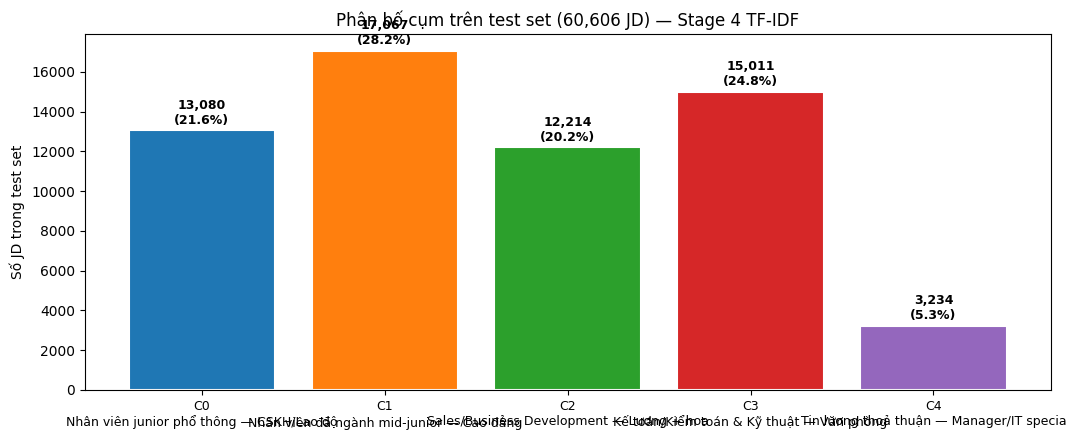

In [ ]:
sizes_tfidf = Counter(labels_test_tfidf.tolist())

fig, ax = plt.subplots(figsize=(11, 4.5))
clusters = sorted(sizes_tfidf.keys())
counts = [sizes_tfidf[c] for c in clusters]
labels_x = [f"C{c}\n{cluster_names_tfidf.get(str(c), str(c))[:40]}"
            for c in clusters]
colors = plt.cm.tab10([c % 10 for c in clusters])

bars = ax.bar(range(len(clusters)), counts, color=colors, edgecolor='white', linewidth=1.5)
ax.set_xticks(range(len(clusters)))
ax.set_xticklabels(labels_x, fontsize=9)
ax.set_ylabel('Số JD trong test set')
ax.set_title(f'Phân bố cụm trên test set ({len(labels_test_tfidf):,} JD) — Stage 4 TF-IDF')
for bar, count in zip(bars, counts):
    pct = count / len(labels_test_tfidf) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Visualization — 2D scatter test sample colored by cluster

t-SNE trên 5k mẫu test (stratified per cluster) — show cluster structure rõ trong feature space giảm chiều.

t-SNE trên 5,000 test sample × 150D...
  Done in 5.8s


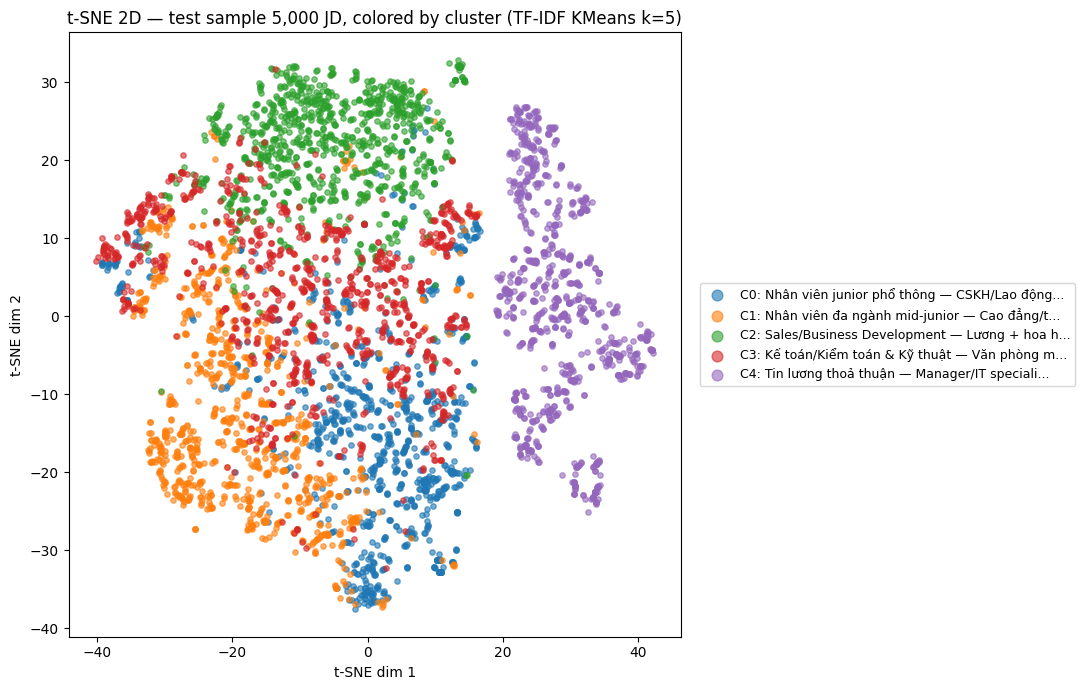

In [11]:
from sklearn.manifold import TSNE
from scipy import sparse

# Load test features SVD-reduced (đã có sẵn từ stage 3)
X_test_svd = np.load(FEATURES / 'X_test_svd.npy')
from sklearn.preprocessing import normalize
X_test_n = normalize(X_test_svd, norm='l2').astype(np.float32)

# Stratified sample 5k để t-SNE nhanh
TSNE_N = 5_000
K = len(set(labels_test_tfidf.tolist()))
per_c = TSNE_N // K
rng = np.random.RandomState(42)
idx_list = []
for c in sorted(set(labels_test_tfidf.tolist())):
    ci = np.where(labels_test_tfidf == c)[0]
    n = min(per_c, len(ci))
    idx_list.append(rng.choice(ci, n, replace=False))
tsne_idx = np.concatenate(idx_list)

X_in = X_test_n[tsne_idx]
y_in = labels_test_tfidf[tsne_idx]

import time
print(f"t-SNE trên {len(tsne_idx):,} test sample × {X_test_n.shape[1]}D...")
t0 = time.time()
tsne = TSNE(n_components=2, perplexity=30, max_iter=500,
            random_state=42, init='pca', n_jobs=-1)
X_2d = tsne.fit_transform(X_in)
print(f"  Done in {time.time()-t0:.1f}s")

fig, ax = plt.subplots(figsize=(11, 7))
for c in sorted(set(y_in.tolist())):
    mask = y_in == c
    name = cluster_names_tfidf.get(str(c), f'C{c}')
    if len(name) > 45:
        name = name[:42] + '...'
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=[plt.cm.tab10(c % 10)], s=15, alpha=0.6,
               label=f'C{c}: {name}')

ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')
ax.set_title(f't-SNE 2D — test sample {len(tsne_idx):,} JD, colored by cluster (TF-IDF KMeans k={K})')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, markerscale=2)
plt.tight_layout()
plt.show()

## 5. Tổng kết kết quả

**2 pipeline được training:**
- Stage 4: TF-IDF + SVD 150D + MiniBatchKMeans (winner)
- Stage 5: SBERT mpnet 768D + MiniBatchKMeans (comparison)

**Finding**: trên dataset JD VN raw (không fine-tune), TF-IDF lexical features cho clustering tốt hơn SBERT semantic embeddings — phù hợp với research literature (SBERT mạnh cho similarity search/classification, không phải raw clustering).

**Cluster interpretation**: xem `cluster_names.json` cho nhãn ý nghĩa của 5 cụm:
- C0, C1: Sales/CSKH junior — mới ra trường, lương ~10tr
- C2: Sales/Business Development senior — high commission, lương ~23tr
- C3: Kế toán/Kiểm toán mid-level — lương ~12tr
- C4: Tin tuyển dụng "lương thoả thuận" — cấp manager/specialist

In [6]:
# Bảng tổng kết
if has_sbert:
    comparison = pd.DataFrame({
        'Stage 4 (TF-IDF)': [
            summary_tfidf['k_final_kmeans'],
            f"{summary_tfidf['final_metrics']['silhouette']:+.4f}",
            f"{summary_tfidf['final_metrics']['davies_bouldin']:.3f}",
            f"{summary_tfidf['final_metrics']['calinski_harabasz']:.0f}",
        ],
        'Stage 5 (SBERT)': [
            summary_sbert['k_final'],
            f"{summary_sbert['final_metrics_kmeans']['silhouette']:+.4f}",
            f"{summary_sbert['final_metrics_kmeans']['davies_bouldin']:.3f}",
            f"{summary_sbert['final_metrics_kmeans']['calinski_harabasz']:.0f}",
        ],
    }, index=['k cụm', 'Silhouette (cao=tốt)', 'Davies-Bouldin (thấp=tốt)', 'Calinski-Harabasz (cao=tốt)'])
else:
    comparison = pd.DataFrame({
        'Stage 4 (TF-IDF)': [
            summary_tfidf['k_final_kmeans'],
            f"{summary_tfidf['final_metrics']['silhouette']:+.4f}",
            f"{summary_tfidf['final_metrics']['davies_bouldin']:.3f}",
            f"{summary_tfidf['final_metrics']['calinski_harabasz']:.0f}",
        ],
    }, index=['k cụm', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz'])

print("=== So sánh 2 pipeline ===")
print(comparison.to_string())
print()
print("Demo notebook chạy xong. Cảm ơn thầy cô đã xem.")

=== So sánh 2 pipeline ===
                            Stage 4 (TF-IDF) Stage 5 (SBERT)
k cụm                                      5               5
Silhouette (cao=tốt)                 +0.1279         +0.0678
Davies-Bouldin (thấp=tốt)              2.206           3.314
Calinski-Harabasz (cao=tốt)             3249            1406

Demo notebook chạy xong. Cảm ơn thầy cô đã xem.
